In [1]:
# Resnet Model for Audio Classification
# I am using features_3_sec.csv for ResNet, the dataset is pre-extracted audio features
# for this implementation, I am using these features as input to a ResNet style model approach
# ResNet is used for images, so we are modifiying it to work with tabular data
# The input is treated as feature vectors instead of 2D images
# The goal is to see how a deep residual network performs on tabular audio features

# then we will be running the real ResNet model on the spectrogram images to compare the results
# I think this is going to interesting to see how the two approaches perform on the same dataset,
# one using pre-extracted features and the other using raw spectrogram images

# so we are not comparing a ResNet on extracted features vs a ResNet on spectrogram images 
# we are comaring a ResNet style approach, residual learning on extracted features vs a real ResNet modelon spectrogram images
# the ResNet style approach on extracted features is more of an experiment 
# the ResNet on spectrogram images is the traditional approach





In [2]:
import os, torch, torchaudio
from torch import device, nn, optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
from torch.utils.tensorboard.writer import SummaryWriter
from typing import cast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F

In [3]:
pip install torch torchaudio torchvision

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Step 1: Load the dataset and preprocess it to get spectrograms
data = pd.read_csv("features_300ms_150ms_overlap.csv")

#dropping colmns we dont need
data = data.drop(columns=["filename", "length"])

# Encode the labels
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["label"]) 

# Split the dataset into features and labels
X = data.drop(columns=["label"]).values
y = data["label"].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)


# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)   

In [12]:
# Define dataset class
class MusicGenreDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
    
# Define the ResNet model
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU()
        )

        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        return self.classifier(x)


In [14]:
len(test_dataset)

40116

In [20]:
# Determine the number of classes dynamically
num_classes = len(label_encoder.classes_)

# Instantiate the model
model = TabularResNet(input_dim=X_train.shape[1], num_classes=num_classes)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Setup Tensorboard
writer = SummaryWriter()

#Disabling test for data preprocessing, as we are focusing on training the model with the ResNet architecture.
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_loss += loss.item()
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    writer.add_scalar('Loss/train', total_loss/len(train_loader), epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_acc:.4f}")
writer.close()

# Step 5: Evaluate the model with testing dataset
model.eval()
total_correct: int = 0
total_samples: int = 0
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)

        # Forward Pass
        test_pred_labels = model(features)

        # Accuracy Compilation
        _, predicted = torch.max(test_pred_labels.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
test_accuracy = total_correct / total_samples
print(f'Test Accuracy: {test_accuracy:.4f}')    

# classification report and confusion matrix
all_labels = []
all_predictions = []
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        test_pred_labels = model(features)
        _, predicted = torch.max(test_pred_labels.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))    






Epoch 1/20, Loss: 1.0289, Accuracy: 0.6331
Epoch 2/20, Loss: 0.8065, Accuracy: 0.7146
Epoch 3/20, Loss: 0.7198, Accuracy: 0.7462
Epoch 4/20, Loss: 0.6628, Accuracy: 0.7666
Epoch 5/20, Loss: 0.6196, Accuracy: 0.7817
Epoch 6/20, Loss: 0.5871, Accuracy: 0.7932
Epoch 7/20, Loss: 0.5588, Accuracy: 0.8026
Epoch 8/20, Loss: 0.5364, Accuracy: 0.8104
Epoch 9/20, Loss: 0.5181, Accuracy: 0.8167
Epoch 10/20, Loss: 0.5043, Accuracy: 0.8218
Epoch 11/20, Loss: 0.4882, Accuracy: 0.8284
Epoch 12/20, Loss: 0.4755, Accuracy: 0.8313
Epoch 13/20, Loss: 0.4635, Accuracy: 0.8360
Epoch 14/20, Loss: 0.4540, Accuracy: 0.8388
Epoch 15/20, Loss: 0.4445, Accuracy: 0.8414
Epoch 16/20, Loss: 0.4337, Accuracy: 0.8459
Epoch 17/20, Loss: 0.4281, Accuracy: 0.8491
Epoch 18/20, Loss: 0.4169, Accuracy: 0.8529
Epoch 19/20, Loss: 0.4121, Accuracy: 0.8537
Epoch 20/20, Loss: 0.4044, Accuracy: 0.8569
Test Accuracy: 0.8347
Classification Report:
              precision    recall  f1-score   support

       blues       0.83      

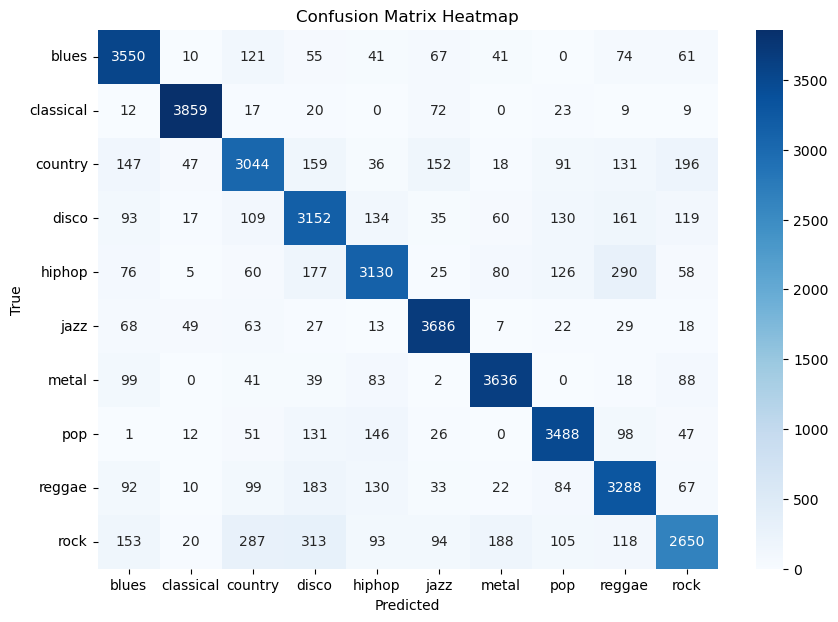

In [21]:
# confusion_matrix heat map
import seaborn as sns
import matplotlib.pyplot as plt 
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()  